**Change the runtype type to R**

**Install / Load Packages for R**

In [75]:
install.packages("RSQLite") # package to connect to databases
install.packages("DBI") # package for SQLite databases
install.packages("ggplot2") # package to create graphs
install.packages("dplyr") # package to work with data tables

library(RSQLite) # use database functions
library(DBI) # use SQLite database tools
library(ggplot2) # use graph making tools
library(dplyr) # use data editing tools

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Load the CLEANED CSV files from GitHub**

In [76]:
app_events <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/app_events_cleaned.csv")

complaints <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/complaints_cleaned.csv")

customers <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/customers_cleaned.csv")

data_dictionary <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/data_dictionary_cleaned.csv")

deliveries <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/deliveries_cleaned.csv")

drivers <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/drivers_cleaned.csv")

hubs <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/hubs_cleaned.csv")

incidents <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/incidents_cleaned.csv")

orders <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/orders_cleaned.csv")

vehicles <- read.csv("https://raw.githubusercontent.com/ayjet24/dba-assignment/main/data/cleaned_csv_files/vehicles_cleaned.csv")

**Create SQLite database in R**

In [77]:
con <- dbConnect (SQLite(), "northstar.db")

dbWriteTable (con, "app_events", app_events, overwrite = TRUE)
dbWriteTable (con, "complaints", complaints, overwrite = TRUE)
dbWriteTable (con, "customers", customers, overwrite = TRUE)
dbWriteTable (con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable (con, "drivers", drivers, overwrite = TRUE)
dbWriteTable (con, "hubs", hubs, overwrite = TRUE)
dbWriteTable (con, "incidents", incidents, overwrite = TRUE)
dbWriteTable (con, "orders", orders, overwrite = TRUE)
dbWriteTable (con, "vehicles", vehicles, overwrite = TRUE)

**Check that the tables are created**

In [78]:
dbListTables(con)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

# **SQL Queries**

**Basic Query**

In [79]:
dbGetQuery (con, "SELECT * FROM orders") # retrieves all the records from the order

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
o00001,c0292,passenger,2024-08-20 14:43:00,6,airport,south,medium,126.65,app,0
o00002,c0459,passenger,2024-05-14 22:16:00,24,north,airport,low,109.30,app,0
o00003,c0161,passenger,2025-09-02 14:37:00,4,west,airport,high,33.50,phone,0
o00004,c0520,parcel,2025-01-11 17:15:00,2,riverside,north,medium,10.04,app,1
o00005,c0558,retail,2025-02-17 19:32:00,12,riverside,south,low,125.58,phone,0
o00006,c0437,retail,2024-08-05 04:55:00,1,central,east,high,151.44,web,1
o00007,c0001,business,2024-05-05 21:32:00,2,central,airport,low,76.12,app,0
o00008,c0157,parcel,2024-04-03 17:54:00,4,riverside,riverside,medium,35.06,phone,0
o00009,c0141,retail,2024-10-03 23:49:00,12,north,east,critical,78.93,app,0


**Basic Query with LIMIT**

In [80]:
dbGetQuery (con, "SELECT * FROM orders LIMIT 5") # retrieves the first 5 records from the order table

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
o00001,c0292,passenger,2024-08-20 14:43:00,6,airport,south,medium,126.65,app,0
o00002,c0459,passenger,2024-05-14 22:16:00,24,north,airport,low,109.30,app,0
o00003,c0161,passenger,2025-09-02 14:37:00,4,west,airport,high,33.50,phone,0
o00004,c0520,parcel,2025-01-11 17:15:00,2,riverside,north,medium,10.04,app,1
o00005,c0558,retail,2025-02-17 19:32:00,12,riverside,south,low,125.58,phone,0


**Count orders by the type of service**

**Counts orders by service type, runs the query and displays the results sorted from highest to lowest.**

In [81]:
# create an sql query to count orders by the type of service
query_count_order <- "
SELECT service_type, COUNT(*) AS total_orders
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC;
"

# run the sql query and store the results
service_type_results <- dbGetQuery (con, query_count_order)

# display the results of the query
service_type_results

service_type,total_orders
<chr>,<int>
passenger,341
parcel,308
retail,297
business,165
medical,139


**Delivery Status Count**

**Counts deliveries by status (on-time, delayed, failed) to look at reliability.**

In [82]:
# sql query to count deliveries by status (on time, delayed, failed)
query_delivery_status <- "
SELECT delivery_status, COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC;
"

# run query + store results
status_delivery_results <- dbGetQuery (con, query_delivery_status)

# display results
status_delivery_results

delivery_status,total_deliveries
<chr>,<int>
ontime,616
delayed,202
failed,132


**Average customer rating by delivery status**

**Average customer rating for each delivery status to see how delays or failures affect customer satisfaction.**

In [83]:
# calculate average customer rating for each delivery status
ratings_status <- "
SELECT delivery_status, AVG(customer_rating_post_delivery) AS avg_rating
FROM deliveries
GROUP BY delivery_status
ORDER BY avg_rating DESC
"

# run the query on the database and results are stored
ratings_status_results <- dbGetQuery (con, ratings_status)

# display the results
ratings_status_results

delivery_status,avg_rating
<chr>,<dbl>
ontime,4.280114
delayed,3.137871
failed,3.056818


**JOIN orders and deliveries by type of service**

**Joins complaints with orders to find the most common complaint types for each service type.**

In [84]:
# combines orders and deliveries tables
service_delivery <- "
  SELECT orders_table.service_type,
  deliveries_table.delivery_status,
  COUNT(*) AS total_deliveries

FROM deliveries deliveries_table
JOIN orders orders_table
ON deliveries_table.order_id = orders_table.order_id
GROUP BY orders_table.service_type, deliveries_table.delivery_status
ORDER BY orders_table.service_type, total_deliveries DESC;
"

# run the sql query and results are stored
service_delivery_results <- dbGetQuery (con, service_delivery)

# display the results table
service_delivery_results

service_type,delivery_status,total_deliveries
<chr>,<chr>,<int>
business,ontime,73
business,delayed,28
business,failed,25
medical,ontime,70
medical,delayed,22
medical,failed,16
parcel,ontime,156
parcel,delayed,49
parcel,failed,25


**Vehicle maintenance and battery health**


**Compares battery health by maintenance status to investigate whether repairs and maintenance are linked to lower battery health and increased vehicle downtime.**

In [85]:
# counts the number of vehicles in each maintenance status
# and calculates the average battery health %
vehicle_maintenance <- "
SELECT
  maintenance_status,
  COUNT(*) AS total_vehicles,
  AVG(battery_health_pct) AS avg_battery_health

FROM vehicles
GROUP BY maintenance_status
ORDER BY avg_battery_health ASC;"

# run the query and results are stored
vehicle_maintenance_results <- dbGetQuery (con, vehicle_maintenance)

# display the table of results
vehicle_maintenance_results

maintenance_status,total_vehicles,avg_battery_health
<chr>,<int>,<dbl>
inrepair,36,76.64167
active,67,76.71343
scheduled,17,77.67059


# **SQL Optimisation Query**

**The optimisation query improves the performance of the database as it reduces the time and resources for data retrieval. A typical technique is creating indexes on commonly searched or columns that are joined, like order_id or customer_id.**

**Create indexes:**

In [86]:
# create indexes to help the database retrieve data quicker
# indexes improve performance of the query when tables are being searched or joined

# create an index for: order_id in orders table
dbExecute (con, "CREATE INDEX IF NOT EXISTS orders_id_orders ON orders(order_id);")

# create an index for: order_id in deliveries table
dbExecute (con, "CREATE INDEX IF NOT EXISTS order_id_deliveries ON deliveries(order_id);")

# create an index for: order_id in complaints table
dbExecute (con, "CREATE INDEX IF NOT EXISTS order_id_complaints ON complaints(order_id);")

# create an index for: customer_id in customers table
dbExecute (con, "CREATE INDEX IF NOT EXISTS customer_id_customers ON customers(customer_id);")

# create an index for: delivery_status in deliveries table
dbExecute (con, "CREATE INDEX IF NOT EXISTS deliveries_status_index ON deliveries(delivery_status);")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

**Query Plan Explanation**

In [87]:
# here, it is visible how the database will run the query step-by-step
# no data is returned, only the query execution plan is shown

# shows how the database runs a query using delivery_status
dbGetQuery (con, "EXPLAIN QUERY PLAN SELECT * FROM deliveries WHERE delivery_status = 'delayed';")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
3,0,61,SEARCH deliveries USING INDEX deliveries_status_index (delivery_status=?)


In [88]:
# shows how the database can run a join between orders and deliveries using order_id
dbGetQuery (con, "EXPLAIN QUERY PLAN SELECT * FROM deliveries JOIN orders ON deliveries.order_id = orders.order_id;")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
4,0,216,SCAN deliveries
6,0,61,SEARCH orders USING INDEX orders_id_orders (order_id=?)


# **R Analytics and Visualisation**

**In this section, I will use R to perform analysis and create visualisations (charts) from the datasets that were cleaned in Python.**

This is why the following 2 libraries were included:

*   library(ggplot2)
*   library(dplyr)

In [89]:
# summary was used to look at the average customer ratings
# and overall happiness levels, to see if delivery performance is affecting the customer experience
summary (deliveries $ customer_rating_post_delivery)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.373   4.040   3.867   4.550   5.000 

# **Bar Charts**

**The first section below (summary table) is required before creating the actual bar chart as the original dataset for deliveries includes individual delivery records and not the average rating for each delivery status. aggregate calculates the average customer rating for each status like delayed, failed or on time.**

In [90]:
# this calculates the average customer rating for each delivery status
delivery_ratings <- aggregate (
  deliveries $ customer_rating_post_delivery, # i want to average this column
  by = list(deliveries $ delivery_status), # group by delivery status
  FUN = mean # mean/average is calculated
)

# names for the columns
names (delivery_ratings) <- c("delivery_status", "average_rating")

# display results
delivery_ratings

delivery_status,average_rating
<chr>,<dbl>
delayed,3.137871
failed,3.056818
ontime,4.280114


**Average customer rating by delivery status**

**This bar chart analysis compared the different ratings given by customers based on the delivery status. As shown below, the rating is higher when the deliveries have been on time.**

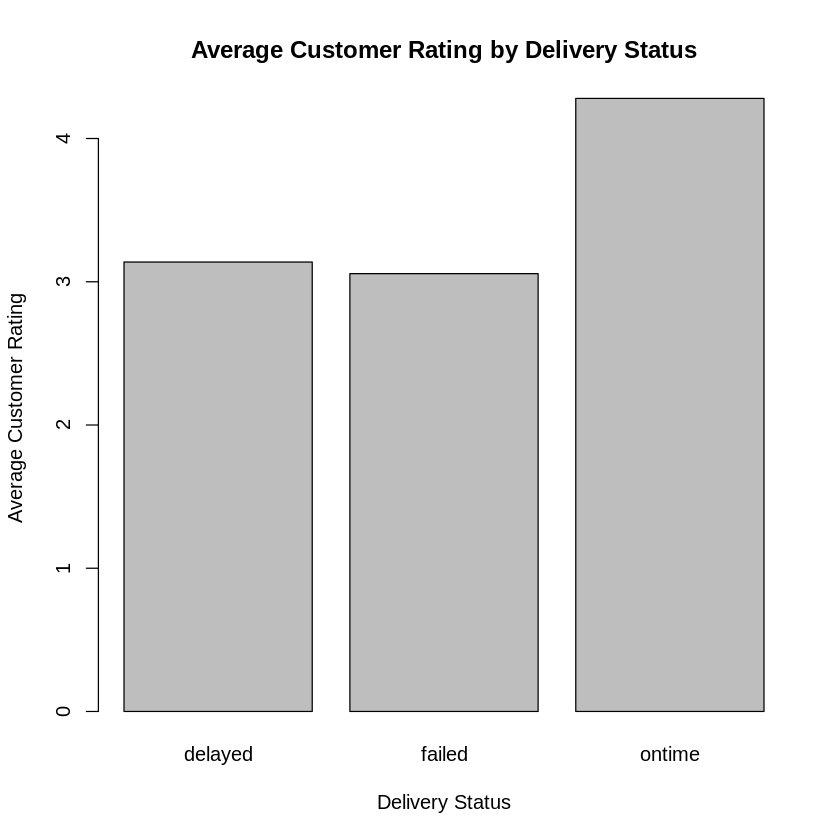

In [91]:
# Create simple bar chart

barplot(
  # values for the height of the bars
  delivery_ratings$average_rating,
  # labels for each bar
  names.arg = delivery_ratings$delivery_status,
  # title for the chart
  main = "Average Customer Rating by Delivery Status",
  # label for x axis
  xlab = "Delivery Status",
  # label for y axis
  ylab = "Average Customer Rating"
)

**Delivery Status Count**

**The first section below counts the number of deliveries that fall into each delivery status, like on-time, delayed or failed. Deliveries are grouped by delivery_status, counts the number of delivery records in every group and saves the results.**

In [92]:
# counts the number of deliveries that are in each delivery status
delivery_status_count <- aggregate(
  # counts the column 'delivery_id'
  deliveries $ delivery_id,
  # group by delivery status
  by = list(deliveries $ delivery_status),
  # counts the number of records in each group
  FUN = length
)

#column mames
names (delivery_status_count) <- c("delivery_status", "total_deliveries")
# results are displayed
delivery_status_count

delivery_status,total_deliveries
<chr>,<int>
delayed,202
failed,132
ontime,616


**This bar chart analysis looks at the number of deliveries and their delivery status. For example, the number of deliveries that were 'on-time' were around 600.**

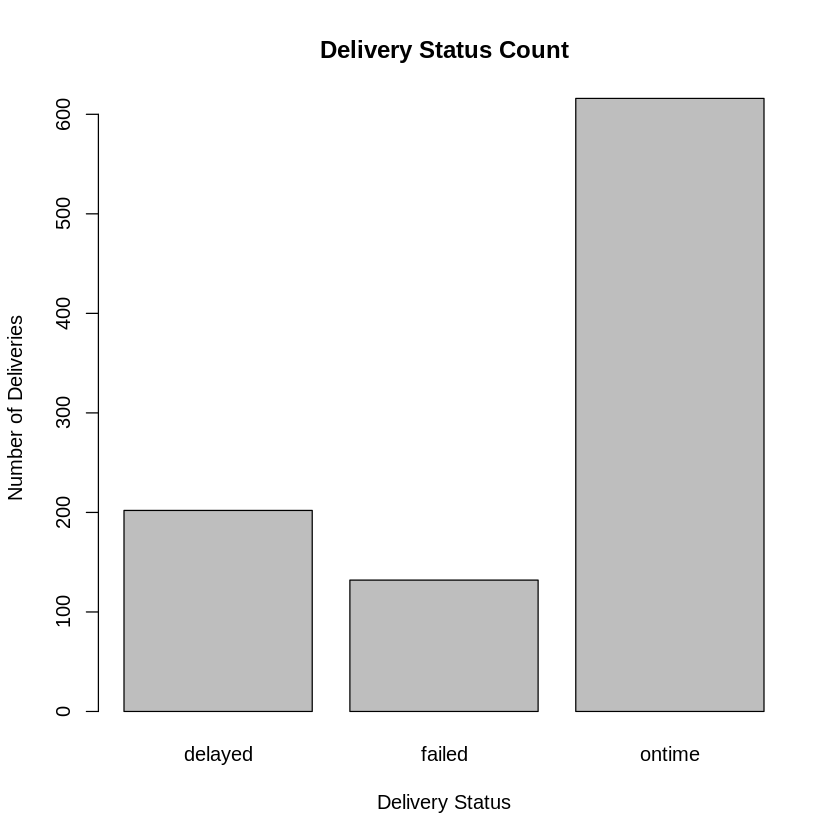

In [93]:
# create a bar chart for delivery status count
barplot (
  # values for the height of the bars
  delivery_status_count $ total_deliveries,
  # labels for each bar
  names.arg = delivery_status_count $ delivery_status,
  # title for the chart
  main = "Delivery Status Count",
  # label for x axis
  xlab = "Delivery Status",
  # label for y axis
  ylab = "Number of Deliveries"
)

**Complaints by Type of complaint**

**The first section counts how many complaints exist for each complaint type.**

In [94]:
# number of complaints are counted for each type of complaint
complaints_by_type <- aggregate(
  # counts the column 'complaint_id'
  complaints $ complaint_id,
  # group by type of complaint
  by = list (complaints $ complaint_type),
  # number of records in each group are counted
  FUN = length
)
# names of columns
names (complaints_by_type) <- c("complaint_type", "total_complaints")
# printed results
complaints_by_type

complaint_type,total_complaints
<chr>,<int>
appissue,53
billing,16
damage,15
delay,101
driverbehaviour,51
missedpickup,64
supportexperience,20


**This bar chart shows how many complaints exist for each complaint type. For example, around 100 complaints were due to delays. NorthStar now know they need to improve this in order to reduce the number of complaints.**

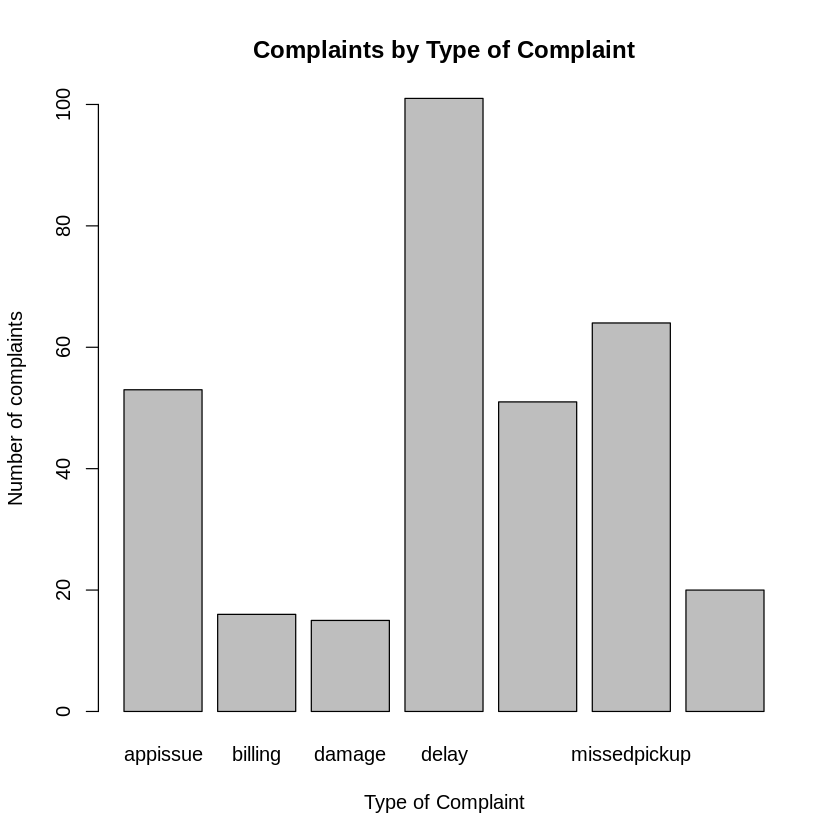

In [95]:
# create a bar chart for complaints by type of complaint
barplot(
  # values for the height of the bars
  complaints_by_type $ total_complaints,
  # labels for each bar
  names.arg = complaints_by_type $ complaint_type,
  # chart title
  main = "Complaints by Type of Complaint",
  # label for x-axis
  xlab = "Type of Complaint",
  # label for y-axis
  ylab = "Number of complaints"
)

**Battery health average by maintenance status**

**This first section calculates the average battery health for each vehicle maintenance status.**

In [96]:
battery_status <- aggregate(
  vehicles $ battery_health_pct,
  by = list (vehicles $ maintenance_status),
  FUN = mean
)

names(battery_status) <- c("maintenance_status", "average_battery_health")

battery_status

maintenance_status,average_battery_health
<chr>,<dbl>
active,76.71343
inrepair,76.64167
scheduled,77.67059


**This bar chart shows the average battery health for each vehicle maintenance status.**

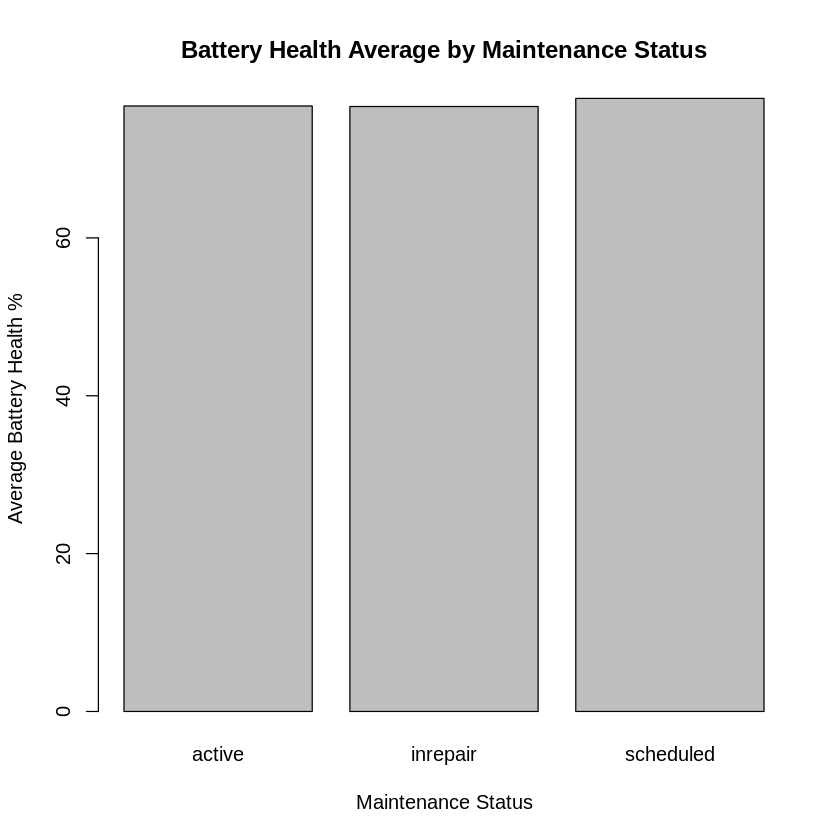

In [97]:
# create a bar chart for complaints by type of complaint
barplot(
  # values for the height of the bars
 battery_status $ average_battery_health,
  # labels for each bar
  names.arg = battery_status $ maintenance_status,
  # chart title
  main = "Battery Health Average by Maintenance Status",
  # label for x-axis
  xlab = "Maintenance Status",
  # label for y-axis
  ylab = "Average Battery Health %"
)